In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, sys
import json
import torch
import pandas as pd
import numpy as np
SAVE_PATH = '/content/drive/MyDrive/2026-1/NLP/appraisal/nlp-appraisal/data'
REPO_ROOT = os.path.dirname(SAVE_PATH)
sys.path.append(REPO_ROOT)

In [ ]:
checkpoint = torch.load(REPO_ROOT + '/checkpoints/best_model_1.pt', map_location='cpu')
print(type(checkpoint))
print(len(checkpoint))

<class 'collections.OrderedDict'>
201


In [ ]:
log = pd.read_csv(REPO_ROOT + '/outputs/training_log_1.csv')
print(log)

   epoch  avg_train_loss  avg_val_loss  goal_relevance_rmse  \
0      1        0.017639      0.112773             0.315641   
1      2        0.015330      0.113617             0.317355   
2      3        0.013860      0.109815             0.317266   
3      4        0.012361      0.111618             0.317957   
4      5        0.010836      0.115102             0.328202   

   self_responsblt_rmse  other_responsblt_rmse  chance_responsblt_rmse  \
0              0.331489               0.345313                0.364389   
1              0.320346               0.330120                0.383610   
2              0.325765               0.330146                0.364745   
3              0.324156               0.327979                0.364138   
4              0.329690               0.333071                0.360865   

   goal_support_rmse  predict_conseq_rmse  urgency_rmse  self_control_rmse  \
0           0.306063             0.332673      0.343889           0.332746   
1           0.292081

In [8]:
# Table 8 from Troiano et al. (2023) - RoBERTa-large T->A model RMSE (1-5 scale)
# Mapped to 15 target dimensions
paper_rmse = {
    'goal_relevance':    1.57,
    'self_responsblt':   1.40,
    'other_responsblt':  1.57,
    'chance_responsblt': 1.43,
    'goal_support':      1.33,
    'predict_conseq':    1.50,
    'urgency':           1.43,
    'self_control':      1.35,
    'other_control':     1.36,
    'chance_control':    1.35,
    'accept_conseq':     1.44,
    'social_norms':      1.34,
    'standards':         1.36,
    'attention':         1.27,
    'effort':            1.38,
}

In [22]:
def analyze_training_log(log):
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 5))
    plt.plot(log['epoch'], log['avg_train_loss'], label='Train Loss')
    plt.plot(log['epoch'], log['avg_val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.show()
    print("Best epoch row:")
    best_epoch_row = log.loc[log['avg_val_loss'].idxmin()]
    print(best_epoch_row)
    print("Per-dimension RMSE table for best epoch:")
    rmse_columns = [col for col in log.columns if col.endswith('_rmse')]
    rmse_dict = {col.replace('_rmse', ''): best_epoch_row[col] for col in rmse_columns}
    rmse_df = pd.DataFrame(list(rmse_dict.items()), columns=['Dimension', 'RMSE'])
    return rmse_dict, rmse_df

def compare_to_paper(rmse_dict, paper_rmse_dict):
    comparison_df = pd.DataFrame({
        'dimension': list(rmse_dict.keys()),
        'model_rmse_scaled': [val * 4 for val in rmse_dict.values()],
        'paper_rmse': [paper_rmse_dict[dim] for dim in rmse_dict.keys()],
        'difference': [rmse_dict[dim] * 4 - paper_rmse_dict[dim] for dim in rmse_dict.keys()],      
        'better_than_paper': [rmse_dict[dim] * 4 < paper_rmse_dict[dim] for dim in rmse_dict.keys()]
    })
    # Return two dfs: one df showing dimensions where paper outperforms this model and how much rounded to 4 decimal places and the other comparison_df
    worse_than_paper_df = comparison_df.loc[comparison_df['better_than_paper'] == False, ['dimension', 'difference']].copy()
    worse_than_paper_df['difference'] = worse_than_paper_df['difference'].round(4)
    return worse_than_paper_df, comparison_df

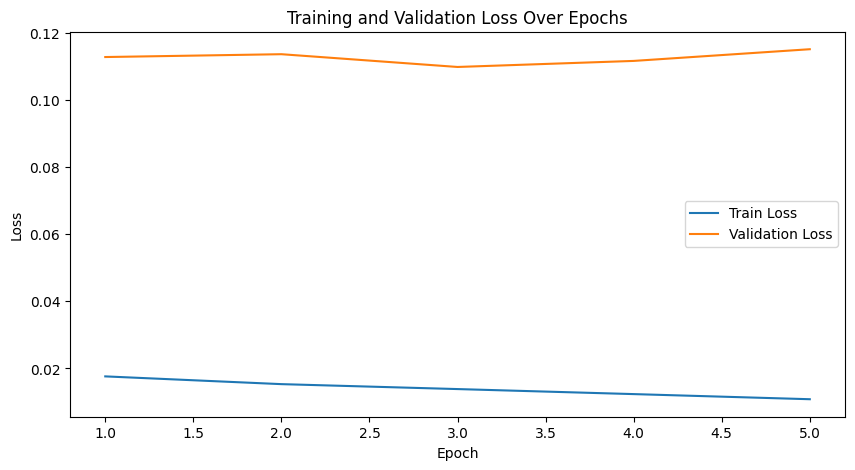

Best epoch row:
epoch                     3.000000
avg_train_loss            0.013860
avg_val_loss              0.109815
goal_relevance_rmse       0.317266
self_responsblt_rmse      0.325765
other_responsblt_rmse     0.330146
chance_responsblt_rmse    0.364745
goal_support_rmse         0.285044
predict_conseq_rmse       0.333440
urgency_rmse              0.337986
self_control_rmse         0.314882
other_control_rmse        0.321206
chance_control_rmse       0.360424
accept_conseq_rmse        0.359123
social_norms_rmse         0.326744
standards_rmse            0.333721
attention_rmse            0.337353
effort_rmse               0.313948
Name: 2, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.31726557), 'self_responsblt': np.float64(0.32576537), 'other_responsblt': np.float64(0.330146), 'chance_responsblt': np.float64(0.36474514), 'goal_support': np.float64(0.28504393), 'predict_conseq': np.float64(0.33343974), 'urgency': np.float64(0.33798596),

In [27]:
# Analyze the first training log
rmse_dict, rmse_df = analyze_training_log(log)
worse_than_paper_df,comparison_df = compare_to_paper(rmse_dict, paper_rmse)
print(rmse_dict)
print(rmse_df)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict.values())).round(4) * 4)
print(comparison_df)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df)